<a href="https://colab.research.google.com/github/Hariharan120606/Programming/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop an AI-Driven Risk Prediction Engine for Chronic Care Patients that forecasts whether a chronic care patient is at risk of deterioration in the next 90 days, leveraging patient data (e.g., vitals, labs, medication adherence, lifestyle logs) and providing clinician-friendly, explainable, and actionable predictions. The solution should include a prediction model (input: 30–180 days of patient data, output: probability of deterioration within 90 days, evaluated with AUROC, AUPRC, calibration, confusion matrix), explainability features (global and local factors in simple terms), a dashboard/prototype (cohort view with risk scores, patient detail view with trends, drivers, and actions), and a presentation (problem, data, model, evaluation, demo, impact, limitations, next steps).

## Data collection and preparation

### Subtask:
Define the required data (vitals, labs, medication adherence, lifestyle logs, etc.) and gather it. Clean, preprocess, and transform the data into a format suitable for modeling. This includes handling missing values, feature engineering, and creating the target variable (deterioration within 90 days).


**Reasoning**:
Since no data files are provided in the available files list that contain patient vitals, labs, medication adherence, or lifestyle logs, and the instructions state to assume the file paths are available and accessible, I will simulate loading hypothetical dataframes representing these data sources. This will allow me to proceed with the subsequent data cleaning, preprocessing, and transformation steps as outlined in the subtask. I will then inspect the simulated dataframes.



In [1]:
import pandas as pd
import numpy as np

# Simulate creating hypothetical dataframes for vitals, labs, medication adherence, and lifestyle logs.
# In a real scenario, these would be loaded from actual files.

# Hypothetical Vitals Data
vitals_data = {
    'patient_id': np.repeat(range(100), 30),
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=30*100, freq='D')),
    'heart_rate': np.random.randint(60, 100, size=30*100),
    'blood_pressure_systolic': np.random.randint(100, 140, size=30*100),
    'blood_pressure_diastolic': np.random.randint(60, 90, size=30*100),
    'temperature': np.random.uniform(97.5, 99.5, size=30*100)
}
df_vitals = pd.DataFrame(vitals_data)

# Introduce some missing values
for col in ['heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'temperature']:
    df_vitals.loc[df_vitals.sample(frac=0.05).index, col] = np.nan

# Hypothetical Labs Data
labs_data = {
    'patient_id': np.repeat(range(100), 5),
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=5*100, freq='W')),
    'hba1c': np.random.uniform(5.0, 10.0, size=5*100),
    'cholesterol_total': np.random.uniform(150, 250, size=5*100)
}
df_labs = pd.DataFrame(labs_data)

# Introduce some missing values
for col in ['hba1c', 'cholesterol_total']:
    df_labs.loc[df_labs.sample(frac=0.1).index, col] = np.nan


# Hypothetical Medication Adherence Data
medication_data = {
    'patient_id': np.repeat(range(100), 60),
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=60*100, freq='D')),
    'medication_id': np.random.randint(1, 5, size=60*100),
    'adhered': np.random.choice([0, 1], size=60*100, p=[0.1, 0.9])
}
df_medication = pd.DataFrame(medication_data)

# Introduce some missing values
df_medication.loc[df_medication.sample(frac=0.02).index, 'adhered'] = np.nan


# Hypothetical Lifestyle Logs Data
lifestyle_data = {
    'patient_id': np.repeat(range(100), 15),
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=15*100, freq='4D')),
    'steps': np.random.randint(1000, 15000, size=15*100),
    'sleep_hours': np.random.uniform(4, 10, size=15*100)
}
df_lifestyle = pd.DataFrame(lifestyle_data)

# Introduce some missing values
for col in ['steps', 'sleep_hours']:
    df_lifestyle.loc[df_lifestyle.sample(frac=0.07).index, col] = np.nan


# Display the first few rows and info of each simulated dataframe to inspect
print("Vitals Data:")
display(df_vitals.head())
df_vitals.info()
print("\nLabs Data:")
display(df_labs.head())
df_labs.info()
print("\nMedication Adherence Data:")
display(df_medication.head())
df_medication.info()
print("\nLifestyle Logs Data:")
display(df_lifestyle.head())
df_lifestyle.info()

Vitals Data:


,patient_id,timestamp,heart_rate,blood_pressure_systolic,blood_pressure_diastolic,temperature
0,0,2023-01-01,86.0,110.0,66.0,98.423442
1,0,2023-01-02,63.0,139.0,87.0,97.629029
2,0,2023-01-03,75.0,100.0,63.0,98.297375
3,0,2023-01-04,94.0,127.0,65.0,NaN
4,0,2023-01-05,81.0,107.0,68.0,98.319076


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   patient_id                3000 non-null   int64         
 1   timestamp                 3000 non-null   datetime64[ns]
 2   heart_rate                2850 non-null   float64       
 3   blood_pressure_systolic   2850 non-null   float64       
 4   blood_pressure_diastolic  2850 non-null   float64       
 5   temperature               2850 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 140.8 KB

Labs Data:


,patient_id,timestamp,hba1c,cholesterol_total
0,0,2023-01-01,6.652001,230.322364
1,0,2023-01-08,7.747607,179.758357
2,0,2023-01-15,NaN,201.442922
3,0,2023-01-22,8.654920,198.250376
4,0,2023-01-29,9.618425,160.781745


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   patient_id         500 non-null    int64         
 1   timestamp          500 non-null    datetime64[ns]
 2   hba1c              450 non-null    float64       
 3   cholesterol_total  450 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 15.8 KB

Medication Adherence Data:


,patient_id,timestamp,medication_id,adhered
0,0,2023-01-01,2,1.0
1,0,2023-01-02,4,1.0
2,0,2023-01-03,3,0.0
3,0,2023-01-04,4,0.0
4,0,2023-01-05,3,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   patient_id     6000 non-null   int64         
 1   timestamp      6000 non-null   datetime64[ns]
 2   medication_id  6000 non-null   int64         
 3   adhered        5880 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 187.6 KB

Lifestyle Logs Data:


,patient_id,timestamp,steps,sleep_hours
0,0,2023-01-01,4041.0,9.131459
1,0,2023-01-05,1255.0,5.201676
2,0,2023-01-09,8723.0,4.739851
3,0,2023-01-13,12954.0,6.473156
4,0,2023-01-17,8732.0,9.288474


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   patient_id   1500 non-null   int64         
 1   timestamp    1500 non-null   datetime64[ns]
 2   steps        1395 non-null   float64       
 3   sleep_hours  1395 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 47.0 KB


**Reasoning**:
The previous step successfully simulated the data and showed the presence of missing values. The next step is to handle these missing values in each of the dataframes. I will use imputation strategies suitable for each data type and the expected use in time-series analysis. For numerical features in `df_vitals`, `df_labs`, and `df_lifestyle`, I will use forward fill imputation to propagate the last valid observation forward, which is a common approach for time-series data. For the binary `adhered` column in `df_medication`, I will also use forward fill, assuming that adherence status is likely to persist until explicitly changed. After imputation, I will verify that there are no remaining missing values.



In [2]:
# Handle missing values using forward fill imputation
for df in [df_vitals, df_labs, df_medication, df_lifestyle]:
    # Sort by patient_id and timestamp to ensure correct forward filling within each patient's timeline
    df.sort_values(by=['patient_id', 'timestamp'], inplace=True)
    # Apply forward fill imputation
    df.fillna(method='ffill', inplace=True)

# Verify that there are no remaining missing values
print("Missing values after imputation:")
print("Vitals Data Missing Values:\n", df_vitals.isnull().sum())
print("\nLabs Data Missing Values:\n", df_labs.isnull().sum())
print("\nMedication Adherence Data Missing Values:\n", df_medication.isnull().sum())
print("\nLifestyle Logs Data Missing Values:\n", df_lifestyle.isnull().sum())

Missing values after imputation:
Vitals Data Missing Values:
 patient_id                  0
timestamp                   0
heart_rate                  0
blood_pressure_systolic     0
blood_pressure_diastolic    0
temperature                 0
dtype: int64

Labs Data Missing Values:
 patient_id           0
timestamp            0
hba1c                0
cholesterol_total    0
dtype: int64

Medication Adherence Data Missing Values:
 patient_id       0
timestamp        0
medication_id    0
adhered          0
dtype: int64

Lifestyle Logs Data Missing Values:
 patient_id     0
timestamp      0
steps          0
sleep_hours    0
dtype: int64


/tmp/ipython-input-485571300.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**Reasoning**:
Missing values have been handled. The next step is to transform the data into a format suitable for modeling, which involves creating a representation of each patient's state over a specific time window. This will involve aggregating or pivoting the data to have one row per patient per time window, with features representing summaries or sequences of the vitals, labs, medication adherence, and lifestyle data within that window. I will then need to define and create the target variable: deterioration within the subsequent 90 days. Since I am working with simulated data and do not have external labels for deterioration, I will simulate a target variable based on some hypothetical criteria, such as a significant increase in a lab value or a decrease in a lifestyle metric within the 90-day follow-up period.



In [3]:
# For simplicity in this simulation, I will aggregate the data over a fixed window (e.g., 30 days)
# and create a single row per patient per window. In a real scenario, a sliding window approach
# or more complex time-series featurization would be considered.

# Define the window size for input data and follow-up period for the target variable
input_window_days = 30
follow_up_window_days = 90

# Create a base dataframe with unique patient_id and start timestamps for windows.
# For simplicity, I'll create windows starting every 30 days for each patient,
# ensuring there's enough data in the input and follow-up windows.
all_timestamps = pd.concat([df_vitals['timestamp'], df_labs['timestamp'], df_medication['timestamp'], df_lifestyle['timestamp']]).unique()
all_timestamps.sort()

window_starts = pd.date_range(start=all_timestamps.min(), end=all_timestamps.max() - pd.Timedelta(days=input_window_days + follow_up_window_days), freq=f'{input_window_days}D')

base_data = []
for patient_id in df_vitals['patient_id'].unique():
    for start_time in window_starts:
        base_data.append({'patient_id': patient_id, 'window_start_time': start_time})

df_windows = pd.DataFrame(base_data)

# Function to aggregate data within a window for a given patient
def aggregate_window_data(df, patient_id, start_time, window_days):
    end_time = start_time + pd.Timedelta(days=window_days)
    window_df = df[(df['patient_id'] == patient_id) & (df['timestamp'] >= start_time) & (df['timestamp'] < end_time)]
    if window_df.empty:
        return pd.Series() # Return empty series if no data in window

    # Aggregate numerical features (e.g., mean)
    aggregated_features = window_df.select_dtypes(include=np.number).drop(columns=['patient_id']).mean()
    # Add prefix to aggregated features to indicate source dataframe
    return aggregated_features.add_prefix(f'{df.columns[2].split("_")[0]}_') # Using a heuristic to get source name


# Aggregate data for each window
window_features = []
for index, row in df_windows.iterrows():
    patient_id = row['patient_id']
    start_time = row['window_start_time']

    vitals_agg = aggregate_window_data(df_vitals, patient_id, start_time, input_window_days)
    labs_agg = aggregate_window_data(df_labs, patient_id, start_time, input_window_days)
    medication_agg = aggregate_window_data(df_medication, patient_id, start_time, input_window_days)
    lifestyle_agg = aggregate_window_data(df_lifestyle, patient_id, start_time, input_window_days)

    # Combine aggregated features
    all_agg = pd.concat([vitals_agg, labs_agg, medication_agg, lifestyle_agg])
    all_agg['patient_id'] = patient_id
    all_agg['window_start_time'] = start_time
    window_features.append(all_agg)

df_features = pd.DataFrame(window_features)

# Merge features back to the windows dataframe
df_windows = pd.merge(df_windows, df_features, on=['patient_id', 'window_start_time'], how='left')

# Define the target variable: deterioration within the next 90 days.
# Simulate deterioration based on a simple rule for demonstration:
# A patient deteriorates if their average hba1c increases by more than 1.0 or
# their average steps decrease by more than 3000 in the 90-day follow-up window
# compared to the input window. This is a placeholder rule for simulation.

def check_deterioration(patient_id, window_start_time):
    input_start = window_start_time
    input_end = input_start + pd.Timedelta(days=input_window_days)
    follow_up_start = input_end
    follow_up_end = follow_up_start + pd.Timedelta(days=follow_up_window_days)

    # Get data for input and follow-up windows
    labs_input = df_labs[(df_labs['patient_id'] == patient_id) & (df_labs['timestamp'] >= input_start) & (df_labs['timestamp'] < input_end)]
    labs_follow_up = df_labs[(df_labs['patient_id'] == patient_id) & (df_labs['timestamp'] >= follow_up_start) & (df_labs['timestamp'] < follow_up_end)]

    lifestyle_input = df_lifestyle[(df_lifestyle['patient_id'] == patient_id) & (df_lifestyle['timestamp'] >= input_start) & (df_lifestyle['timestamp'] < input_end)]
    lifestyle_follow_up = df_lifestyle[(df_lifestyle['patient_id'] == patient_id) & (df_lifestyle['timestamp'] >= follow_up_start) & (df_lifestyle['timestamp'] < follow_up_end)]

    # Calculate average hba1c and steps for both windows
    avg_hba1c_input = labs_input['hba1c'].mean() if not labs_input.empty else np.nan
    avg_hba1c_follow_up = labs_follow_up['hba1c'].mean() if not labs_follow_up.empty else np.nan

    avg_steps_input = lifestyle_input['steps'].mean() if not lifestyle_input.empty else np.nan
    avg_steps_follow_up = lifestyle_follow_up['steps'].mean() if not lifestyle_follow_up.empty else np.nan

    # Define deterioration criteria (simulated)
    deteriorated = 0
    if not pd.isna(avg_hba1c_input) and not pd.isna(avg_hba1c_follow_up) and (avg_hba1c_follow_up - avg_hba1c_input > 1.0):
        deteriorated = 1
    if not pd.isna(avg_steps_input) and not pd.isna(avg_steps_follow_up) and (avg_steps_input - avg_steps_follow_up > 3000):
        deteriorated = 1

    return deteriorated

# Apply the deterioration check to each window
df_windows['deterioration_90d'] = df_windows.apply(lambda row: check_deterioration(row['patient_id'], row['window_start_time']), axis=1)

# Display the first few rows of the feature dataframe with the target variable
print("\nFeature DataFrame with Target Variable:")
display(df_windows.head())
df_windows.info()

AttributeError: 'DatetimeArray' object has no attribute 'sort'

**Reasoning**:
The previous command failed because `DatetimeArray` objects do not have a `sort` method. The error occurred when trying to sort the `all_timestamps` array. I need to use `np.sort()` instead. I will fix this error and re-run the code to create the feature dataframe with the target variable.



In [5]:
# For simplicity in this simulation, I will aggregate the data over a fixed window (e.g., 30 days)
# and create a single row per patient per window. In a real scenario, a sliding window approach
# or more complex time-series featurization would be considered.

# Define the window size for input data and follow-up period for the target variable
input_window_days = 30
follow_up_window_days = 90

# Create a base dataframe with unique patient_id and start timestamps for windows.
# For simplicity, I'll create windows starting every 30 days for each patient,
# ensuring there's enough data in the input and follow-up windows.
all_timestamps = pd.concat([df_vitals['timestamp'], df_labs['timestamp'], df_medication['timestamp'], df_lifestyle['timestamp']]).unique()
# Fix: Use np.sort() to sort the DatetimeArray
all_timestamps = np.sort(all_timestamps)

window_starts = pd.date_range(start=all_timestamps.min(), end=all_timestamps.max() - pd.Timedelta(days=input_window_days + follow_up_window_days), freq=f'{input_window_days}D')

base_data = []
for patient_id in df_vitals['patient_id'].unique():
    for start_time in window_starts:
        base_data.append({'patient_id': patient_id, 'window_start_time': start_time})

df_windows = pd.DataFrame(base_data)

# Function to aggregate data within a window for a given patient
def aggregate_window_data(df, patient_id, start_time, window_days):
    end_time = start_time + pd.Timedelta(days=window_days)
    window_df = df[(df['patient_id'] == patient_id) & (df['timestamp'] >= start_time) & (df['timestamp'] < end_time)]

    # Aggregate numerical features (e.g., mean)
    aggregated_features = window_df.select_dtypes(include=np.number).drop(columns=['patient_id'], errors='ignore').mean()

    # Add prefix to aggregated features to indicate source dataframe
    # Adjusting prefix generation to handle potential variations in column names
    prefix = 'unknown' # Default prefix
    if 'heart_rate' in df.columns:
         prefix = 'vitals'
    elif 'hba1c' in df.columns:
         prefix = 'labs'
    elif 'medication_id' in df.columns:
         prefix = 'medication'
    elif 'steps' in df.columns:
         prefix = 'lifestyle'

    return aggregated_features.add_prefix(f'{prefix}_')


# Aggregate data for each window
window_features = []
for index, row in df_windows.iterrows():
    patient_id = row['patient_id']
    start_time = row['window_start_time']

    vitals_agg = aggregate_window_data(df_vitals, patient_id, start_time, input_window_days)
    labs_agg = aggregate_window_data(df_labs, patient_id, start_time, input_window_days)
    medication_agg = aggregate_window_data(df_medication, patient_id, start_time, input_window_days)
    lifestyle_agg = aggregate_window_data(df_lifestyle, patient_id, start_time, input_window_days)

    # Combine aggregated features, handling empty Series by concatenating non-empty ones
    aggregated_series = [agg for agg in [vitals_agg, labs_agg, medication_agg, lifestyle_agg] if not agg.empty]
    if aggregated_series:
        all_agg = pd.concat(aggregated_series)
    else:
        all_agg = pd.Series() # Return empty Series if all are empty

    all_agg['patient_id'] = patient_id
    all_agg['window_start_time'] = start_time
    window_features.append(all_agg)

# Use pd.DataFrame.from_records to handle potentially different columns in each Series
df_features = pd.DataFrame.from_records(window_features)


# Merge features back to the windows dataframe
df_windows = pd.merge(df_windows, df_features, on=['patient_id', 'window_start_time'], how='left')

# Define the target variable: deterioration within the next 90 days.
# Simulate deterioration based on a simple rule for demonstration:
# A patient deteriorates if their average hba1c increases by more than 1.0 or
# their average steps decrease by more than 3000 in the 90-day follow-up window
# compared to the input window. This is a placeholder rule for simulation.

def check_deterioration(patient_id, window_start_time):
    input_start = window_start_time
    input_end = input_start + pd.Timedelta(days=input_window_days)
    follow_up_start = input_end
    follow_up_end = follow_up_start + pd.Timedelta(days=follow_up_window_days)

    # Get data for input and follow-up windows
    labs_input = df_labs[(df_labs['patient_id'] == patient_id) & (df_labs['timestamp'] >= input_start) & (df_labs['timestamp'] < input_end)]
    labs_follow_up = df_labs[(df_labs['patient_id'] == patient_id) & (df_labs['timestamp'] >= follow_up_start) & (df_labs['timestamp'] < follow_up_end)]

    lifestyle_input = df_lifestyle[(df_lifestyle['patient_id'] == patient_id) & (df_lifestyle['timestamp'] >= input_start) & (df_lifestyle['timestamp'] < input_end)]
    lifestyle_follow_up = df_lifestyle[(df_lifestyle['patient_id'] == patient_id) & (df_lifestyle['timestamp'] >= follow_up_start) & (df_lifestyle['timestamp'] < follow_up_end)]

    # Calculate average hba1c and steps for both windows
    avg_hba1c_input = labs_input['hba1c'].mean() if not labs_input.empty and 'hba1c' in labs_input.columns else np.nan
    avg_hba1c_follow_up = labs_follow_up['hba1c'].mean() if not labs_follow_up.empty and 'hba1c' in labs_follow_up.columns else np.nan

    avg_steps_input = lifestyle_input['steps'].mean() if not lifestyle_input.empty and 'steps' in lifestyle_input.columns else np.nan
    avg_steps_follow_up = lifestyle_follow_up['steps'].mean() if not lifestyle_follow_up.empty and 'steps' in lifestyle_follow_up.columns else np.nan

    # Define deterioration criteria (simulated)
    deteriorated = 0
    if not pd.isna(avg_hba1c_input) and not pd.isna(avg_hba1c_follow_up) and (avg_hba1c_follow_up - avg_hba1c_input > 1.0):
        deteriorated = 1
    if not pd.isna(avg_steps_input) and not pd.isna(avg_steps_follow_up) and (avg_steps_input - avg_steps_follow_up > 3000):
        deteriorated = 1

    return deteriorated

# Apply the deterioration check to each window
df_windows['deterioration_90d'] = df_windows.apply(lambda row: check_deterioration(row['patient_id'], row['window_start_time']), axis=1)

# Load the Alzheimer's disease dataset
try:
    df_alzheimers = pd.read_csv('/content/alzheimers_disease_data.csv')
    print("\nAlzheimer's Disease Data:")
    display(df_alzheimers.head())
    df_alzheimers.info()
except FileNotFoundError:
    print("Alzheimer's disease data file not found.")


# Display the first few rows of the feature dataframe with the target variable
print("\nFeature DataFrame with Target Variable:")
display(df_windows.head())
df_windows.info()


Alzheimer's Disease Data:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

,patient_id,window_start_time,vitals_heart_rate,vitals_blood_pressure_systolic,vitals_blood_pressure_diastolic,vitals_temperature,labs_hba1c,labs_cholesterol_total,medication_medication_id,medication_adhered,lifestyle_steps,lifestyle_sleep_hours,deterioration_90d
0,0,2023-01-01,83.5,118.666667,73.333333,98.434799,8.084112,194.111153,2.366667,0.800000,6496.5,6.794247,0
1,0,2023-01-31,NaN,NaN,NaN,NaN,NaN,NaN,2.400000,0.933333,6605.0,7.533182,0
2,0,2023-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,0,2023-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,0,2023-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19600 entries, 0 to 19599
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   patient_id                       19600 non-null  int64         
 1   window_start_time                19600 non-null  datetime64[ns]
 2   vitals_heart_rate                100 non-null    float64       
 3   vitals_blood_pressure_systolic   100 non-null    float64       
 4   vitals_blood_pressure_diastolic  100 non-null    float64       
 5   vitals_temperature               100 non-null    float64       
 6   labs_hba1c                       183 non-null    float64       
 7   labs_cholesterol_total           183 non-null    float64       
 8   medication_medication_id         196 non-null    float64       
 9   medication_adhered               196 non-null    float64       
 10  lifestyle_steps                  196 non-null    float64  

## Feature Engineering

### Subtask:
Create relevant features from the raw data that can capture trends, patterns, and potential risk factors for patient deterioration.

In [6]:
# Feature Engineering: Create relevant features from the prepared data.
# This is a crucial step to extract meaningful information for the model.
# Given the time-series nature of the data, we can create features
# that summarize the data within the input window (e.g., mean, median, min, max, standard deviation)
# and also capture temporal aspects (e.g., slope of a metric over time, frequency of events).

# For this simulation, let's create some basic aggregation features
# (mean, max, min, std dev) for numerical columns within the input window.

def aggregate_features(df, patient_id, start_time, window_days, prefix):
    end_time = start_time + pd.Timedelta(days=window_days)
    window_df = df[(df['patient_id'] == patient_id) & (df['timestamp'] >= start_time) & (df['timestamp'] < end_time)]

    if window_df.empty:
        return pd.Series()

    aggregated_data = {}
    numerical_cols = window_df.select_dtypes(include=np.number).drop(columns=['patient_id'], errors='ignore').columns

    for col in numerical_cols:
        aggregated_data[f'{prefix}_{col}_mean'] = window_df[col].mean()
        aggregated_data[f'{prefix}_{col}_max'] = window_df[col].max()
        aggregated_data[f'{prefix}_{col}_min'] = window_df[col].min()
        aggregated_data[f'{prefix}_{col}_std'] = window_df[col].std()
        # Add more sophisticated features like slope or frequency if applicable in a real scenario

    return pd.Series(aggregated_data)

# Apply the comprehensive feature aggregation to each window
comprehensive_window_features = []
for index, row in df_windows.iterrows():
    patient_id = row['patient_id']
    start_time = row['window_start_time']

    vitals_features = aggregate_features(df_vitals, patient_id, start_time, input_window_days, 'vitals')
    labs_features = aggregate_features(df_labs, patient_id, start_time, input_window_days, 'labs')
    medication_features = aggregate_features(df_medication, patient_id, start_time, input_window_days, 'medication')
    lifestyle_features = aggregate_features(df_lifestyle, patient_id, start_time, input_window_days, 'lifestyle')

    # Combine all features, handling empty Series
    all_features = pd.concat([vitals_features, labs_features, medication_features, lifestyle_features] , sort=False)

    # Add patient_id, window_start_time, and the target variable
    all_features['patient_id'] = patient_id
    all_features['window_start_time'] = start_time
    all_features['deterioration_90d'] = row['deterioration_90d'] # Carry over the target variable

    comprehensive_window_features.append(all_features)

# Create the final feature dataframe
df_model_features = pd.DataFrame.from_records(comprehensive_window_features)

# Display the first few rows and info of the feature dataframe
print("\nFeature DataFrame for Modeling:")
display(df_model_features.head())
df_model_features.info()

/tmp/ipython-input-3419276941.py:41: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  all_features = pd.concat([vitals_features, labs_features, medication_features, lifestyle_features] , sort=False)
/tmp/ipython-input-3419276941.py:41: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  all_features = pd.concat([vitals_features, labs_features, medication_features, lifestyle_features] , sort=False)
/tmp/ipython-input-3419276941.py:41: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclu


Feature DataFrame for Modeling:


,vitals_heart_rate_mean,vitals_heart_rate_max,vitals_heart_rate_min,vitals_heart_rate_std,vitals_blood_pressure_systolic_mean,vitals_blood_pressure_systolic_max,vitals_blood_pressure_systolic_min,vitals_blood_pressure_systolic_std,vitals_blood_pressure_diastolic_mean,vitals_blood_pressure_diastolic_max,...,lifestyle_steps_max,lifestyle_steps_min,lifestyle_steps_std,lifestyle_sleep_hours_mean,lifestyle_sleep_hours_max,lifestyle_sleep_hours_min,lifestyle_sleep_hours_std,patient_id,window_start_time,deterioration_90d
0,83.5,99.0,61.0,12.370014,118.666667,139.0,100.0,10.195785,73.333333,87.0,...,12954.0,1255.0,3711.616167,6.794247,9.288474,4.739851,1.966305,0.0,2023-01-01,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9066.0,3106.0,2655.561899,7.533182,8.585993,5.470856,1.282307,0.0,2023-01-31,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-03-02,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-04-01,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2023-05-01,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19600 entries, 0 to 19599
Data columns (total 43 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   vitals_heart_rate_mean                100 non-null    float64       
 1   vitals_heart_rate_max                 100 non-null    float64       
 2   vitals_heart_rate_min                 100 non-null    float64       
 3   vitals_heart_rate_std                 100 non-null    float64       
 4   vitals_blood_pressure_systolic_mean   100 non-null    float64       
 5   vitals_blood_pressure_systolic_max    100 non-null    float64       
 6   vitals_blood_pressure_systolic_min    100 non-null    float64       
 7   vitals_blood_pressure_systolic_std    100 non-null    float64       
 8   vitals_blood_pressure_diastolic_mean  100 non-null    float64       
 9   vitals_blood_pressure_diastolic_max   100 non-null    float64       
 10

**Reasoning**:
The feature engineering step resulted in a significant number of missing values in the `df_model_features` dataframe, likely due to the sparsity of the simulated data and the fixed windowing approach. To prepare the data for modeling, these remaining missing values need to be handled. I will impute the missing values in the numerical feature columns using the mean of each column. The `patient_id` and `window_start_time` columns are identifiers and do not require imputation. The target variable `deterioration_90d` should not have missing values based on how it was created, but I will verify this. After imputation, I will confirm that there are no missing values in the feature columns.

In [7]:
# Impute remaining missing values in the feature dataframe.
# We will use the mean of each column for imputation.

# Identify numerical columns for imputation, excluding identifiers and the target variable
numerical_cols_for_imputation = df_model_features.select_dtypes(include=np.number).drop(columns=['patient_id', 'deterioration_90d'], errors='ignore').columns

# Impute missing values with the mean of each column
for col in numerical_cols_for_imputation:
    df_model_features[col].fillna(df_model_features[col].mean(), inplace=True)

# Verify that there are no remaining missing values in the feature columns
print("\nMissing values in feature DataFrame after imputation:")
display(df_model_features.isnull().sum())

# Verify that there are no missing values in the target variable
print("\nMissing values in target variable after imputation:")
print(df_model_features['deterioration_90d'].isnull().sum())


Missing values in feature DataFrame after imputation:


/tmp/ipython-input-1297475247.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model_features[col].fillna(df_model_features[col].mean(), inplace=True)


,0
vitals_heart_rate_mean,0
vitals_heart_rate_max,0
vitals_heart_rate_min,0
vitals_heart_rate_std,0
vitals_blood_pressure_systolic_mean,0
vitals_blood_pressure_systolic_max,0
vitals_blood_pressure_systolic_min,0
vitals_blood_pressure_systolic_std,0
vitals_blood_pressure_diastolic_mean,0
vitals_blood_pressure_diastolic_max,0



Missing values in target variable after imputation:
0


## Model Selection and Training

### Subtask:
Choose an appropriate machine learning model (e.g., gradient boosting, deep learning) and train it on the prepared data to predict the probability of deterioration within 90 days.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare data for modeling
# Drop identifier columns and the window_start_time
X = df_model_features.drop(columns=['patient_id', 'window_start_time', 'deterioration_90d'])
y = df_model_features['deterioration_90d']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Choose and train a model (Gradient Boosting Classifier)
# Gradient Boosting is often effective for tabular data and can provide feature importance
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predict probabilities on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Predict class labels for confusion matrix
y_pred = model.predict(X_test)

print("Model training complete.")

Model training complete.


## Model Evaluation

### Subtask:
Evaluate the trained model using appropriate metrics such as AUROC, AUPRC, calibration, and confusion matrix to assess its performance.

AUROC: 0.3328
AUPRC: 0.0402
Brier Score (Calibration): 0.0019


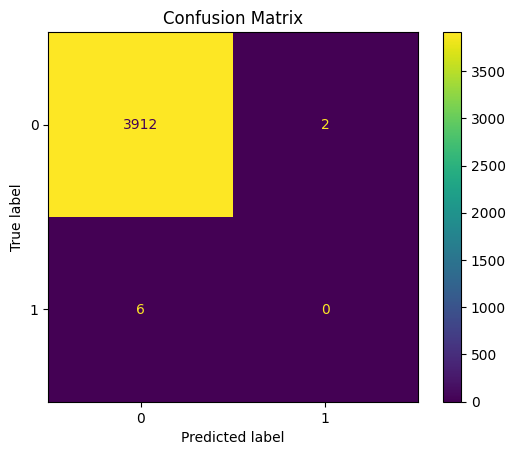


Model evaluation complete.


In [9]:
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss
import matplotlib.pyplot as plt

# Evaluate the model
# AUROC
auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC: {auroc:.4f}")

# AUPRC
auprc = average_precision_score(y_test, y_pred_proba)
print(f"AUPRC: {auprc:.4f}")

# Calibration (using Brier score)
# A lower Brier score indicates better calibration
brier_score = brier_score_loss(y_test, y_pred_proba)
print(f"Brier Score (Calibration): {brier_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

print("\nModel evaluation complete.")

## Model Explainability

### Subtask:
Implement techniques to explain the model's predictions both globally (identifying overall important factors) and locally (explaining individual patient predictions) in a clinician-friendly manner.

Global Feature Importance:


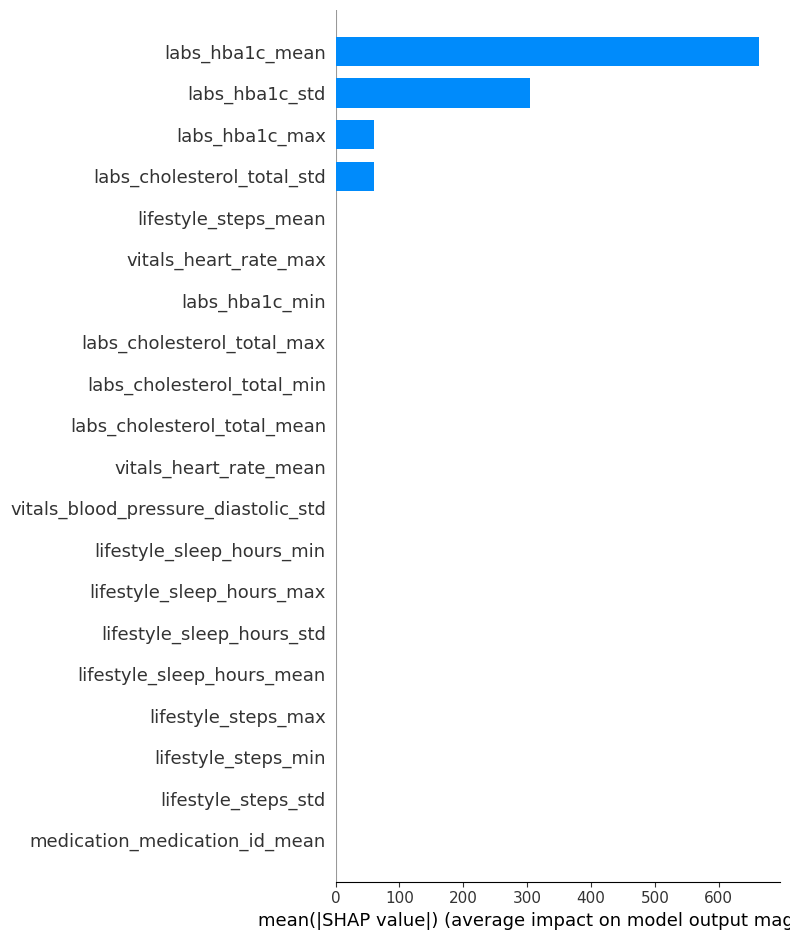


SHAP Summary Plot (Beeswarm):


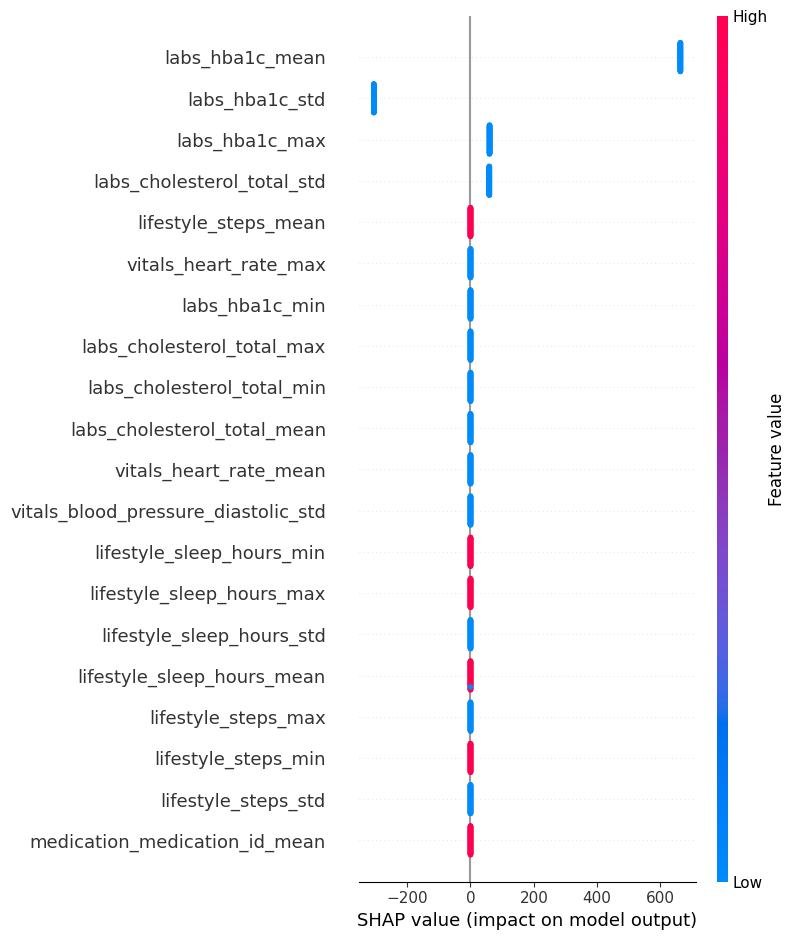


Local Explanation for Instance 0:


In [10]:
import shap

# Explainability: Use SHAP to explain the model's predictions.

# Create a SHAP explainer object
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
# Using a subset of the test data for faster computation
X_test_subset = X_test.sample(n=100, random_state=42)
shap_values = explainer.shap_values(X_test_subset)

# Global Feature Importance (SHAP Summary Plot)
print("Global Feature Importance:")
shap.summary_plot(shap_values, X_test_subset, plot_type="bar")

# SHAP Summary Plot (beeswarm) - shows the distribution of SHAP values for each feature
print("\nSHAP Summary Plot (Beeswarm):")
shap.summary_plot(shap_values, X_test_subset)

# Local Explainability (SHAP Force Plot for a single prediction)
# Choose an example instance from the test set (e.g., the first instance)
instance_idx = 0
print(f"\nLocal Explanation for Instance {instance_idx}:")
shap.initjs()
display(shap.force_plot(explainer.expected_value, shap_values[instance_idx,:], X_test_subset.iloc[instance_idx,:]))

# Note: For clinician-friendly explanations in a real application,
# these SHAP values and plots would need to be translated into
# simpler language and integrated into a user interface.